# 06 — Interpretación y resultados (Deployment / Interpretation)

**Fase CRISP-DM:** Interpretación y resultados (cierre del ciclo CRISP-DM).

**Lee de:** `models/logistic_regression.joblib`, `data/processed/coffee_processed.csv`.

**Produce:** `reports/dashboard/coffee_dashboard.csv` (dataset plano para Power BI/Tableau).

Se interpreta el modelo entrenado en 04 (regresión logística) a través de sus coeficientes: al ser un modelo lineal, cada coeficiente es directamente interpretable como el efecto (en log-odds) de esa variable sobre la probabilidad de que un lote sea "café de especialidad", manteniendo las demás constantes.

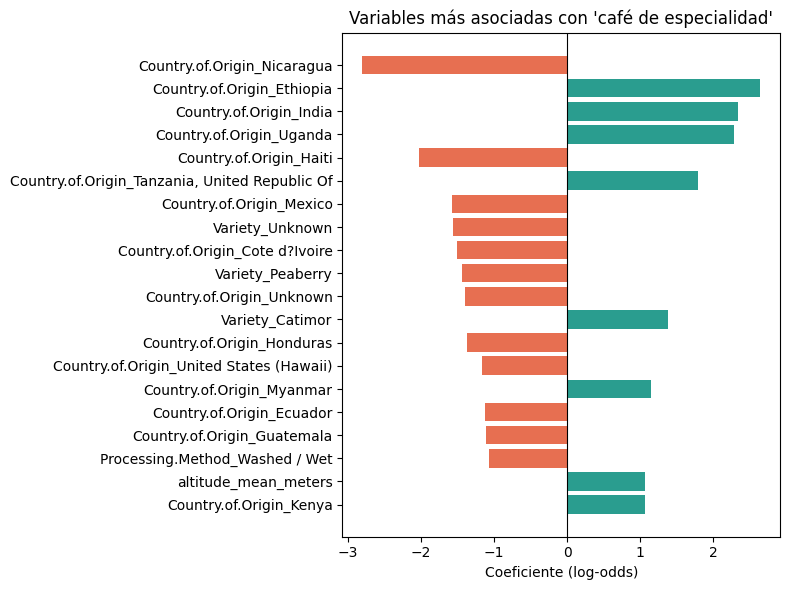

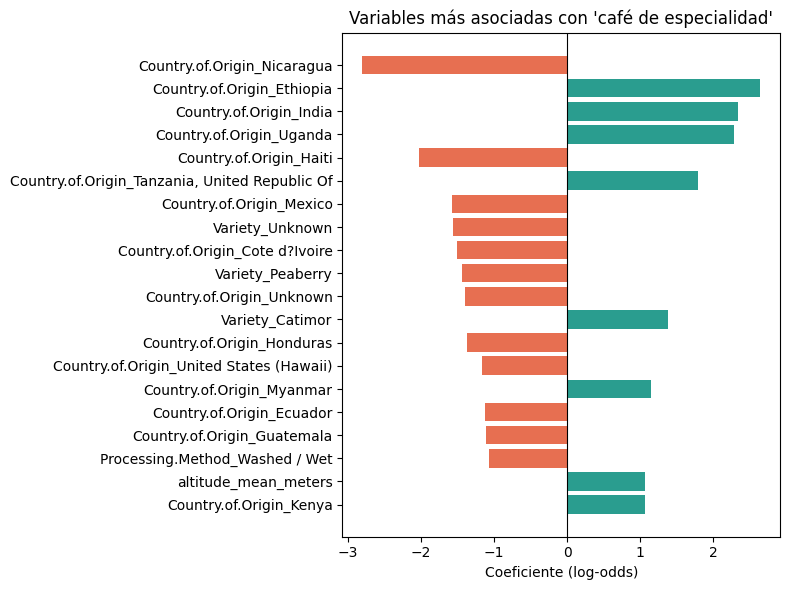

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")  # para poder importar src/ desde notebooks/

import joblib
import pandas as pd

from src.config import load_config, resolve_path
from src.visualization.plots import plot_logistic_coefficients

config = load_config()
models_dir = resolve_path(config["paths"]["models_dir"])
model_pipeline = joblib.load(models_dir / "logistic_regression.joblib")

preprocessor = model_pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
coefficients = model_pipeline.named_steps["classifier"].coef_[0]

plot_logistic_coefficients(feature_names, coefficients, config, "logistic_regression_coeficientes.png")

## Interpretación de negocio

Los coeficientes de mayor magnitud son casi todos de `Country.of.Origin`, lo que sugiere que el **país de origen** es, entre las variables de contexto disponibles, la que más se asocia con la clasificación de "café de especialidad" en este dataset:

- **Asociados positivamente** (mayor probabilidad de ser especialidad): `Ethiopia` (+2.64), `India` (+2.34), `Uganda` (+2.28), `Tanzania` (+1.79), variedad `Catimor` (+1.38), `altitude_mean_meters` (+1.07 — a mayor altitud promedio, mayor probabilidad), y `species_arabica` (+0.99, frente a robusta como categoría base).
- **Asociados negativamente** (menor probabilidad): `Nicaragua` (-2.80), `Haiti` (-2.02), `Mexico` (-1.57), variedad no reportada (`Variety_Unknown`, -1.56), `Cote d'Ivoire` (-1.51), variedad `Peaberry` (-1.43), y `Category.Two.Defects` (-0.57 — más defectos visuales, menor probabilidad, como es esperable).
- **Colombia** tiene un coeficiente positivo moderado (+0.78): en este dataset se asocia con más probabilidad de especialidad que el promedio, aunque muy por debajo de Ethiopia/India/Uganda — es una señal a favor del sector cafetero colombiano, pero no la más fuerte del modelo.

**Implicación para el sector cafetero colombiano** (objetivo de negocio de `01_comprension_del_negocio.ipynb`): la altitud promedio del cultivo es la variable numérica más asociada con la clasificación de especialidad — coherente con la práctica agronómica de que el café arábica de mayor altitud suele desarrollar mejores perfiles de taza. Esto respalda seguir promoviendo/documentando la altitud de cultivo como criterio de calidad, más que enfocarse solo en el volumen de producción (`Number.of.Bags` tiene un coeficiente prácticamente nulo, -0.13).

**Nota de cautela:** varios de los coeficientes más grandes (`Nicaragua`, `Haiti`, `Cote d'Ivoire`, `India`, `Uganda`, `Tanzania`) corresponden a países con pocas observaciones en el dataset combinado — su magnitud puede estar inflada por tamaño de muestra pequeño, no necesariamente por una relación causal fuerte. Estos hallazgos son asociativos (el modelo es correlacional, no causal) y deben tratarse como hipótesis a validar, no como conclusiones definitivas.

## Conclusiones

- Con solo variables de contexto (sin subpuntajes de catación) el modelo alcanza `ROC-AUC ≈ 0.76` y `precision ≈ 0.94` en test: es capaz de anticipar, con buena confiabilidad cuando predice "especialidad", qué lotes lo son a partir de dónde y cómo se cultivaron — no solo de cómo saben en la taza.
- El **país de origen** y la **altitud media de cultivo** son las variables de contexto más asociadas con la clasificación de especialidad en este dataset, más que el tamaño del lote o los defectos visuales.
- El recall moderado (~0.68) indica que el modelo, tal como está, es más útil como señal de apoyo (qué lotes priorizar para catación formal) que como reemplazo del panel de cata SCA.

## Exportación para el dashboard

Dataset plano con las variables de contexto, el target y las predicciones del modelo sobre el conjunto de test, para alimentar un dashboard externo (Power BI/Tableau) que el equipo construya fuera de este repositorio.

In [2]:
processed_dir = resolve_path(config["paths"]["data"]["processed_dir"])
test_df = pd.read_csv(processed_dir / "test.csv")

X_test = test_df[[c for c in test_df.columns if c != config["target"]["target_column"]]]
dashboard_df = test_df.copy()
dashboard_df["prediccion"] = model_pipeline.predict(X_test)
dashboard_df["probabilidad_especialidad"] = model_pipeline.predict_proba(X_test)[:, 1]

dashboard_dir = resolve_path(config["paths"]["reports"]["dashboard_dir"])
dashboard_dir.mkdir(parents=True, exist_ok=True)
dashboard_df.to_csv(dashboard_dir / "coffee_dashboard.csv", index=False)

dashboard_df.head()

,Number.of.Bags,altitude_mean_meters,Moisture,Category.One.Defects,Category.Two.Defects,Quakers,Country.of.Origin,Variety,Processing.Method,Color,species,especialidad,prediccion,probabilidad_especialidad
0,2,1200.0,0.11,0,0,0.0,Taiwan,Typica,Washed / Wet,Blue-Green,arabica,1,1,0.747054
1,2,1650.0,0.13,0,20,0.0,"Tanzania, United Republic Of",Other,Washed / Wet,Green,arabica,1,1,0.741677
2,12,NaN,0.11,2,2,0.0,United States (Hawaii),Hawaiian Kona,Natural / Dry,Bluish-Green,arabica,1,1,0.630418
3,1,1500.0,0.03,0,0,0.0,Indonesia,NaN,NaN,NaN,arabica,1,1,0.839176
4,250,1550.0,0.12,0,5,0.0,Guatemala,Bourbon,Washed / Wet,Green,arabica,1,0,0.360014


## Limitaciones del proyecto

- **Tamaño muestral de robusta:** solo 28 lotes frente a 1311 de arabica; aunque se combinaron con SMOTE tratando el desbalance del *target*, el efecto real de `species` en el modelo se apoya en muy pocas observaciones de robusta y debe leerse con cautela.
- **Dato corrupto:** un lote con `Total.Cup.Points == 0` fue excluido (ver 02/03); si en el futuro se agregan más datos de la misma fuente, vale la pena repetir esta verificación.
- **Representatividad frente a la caficultura colombiana real:** el dataset son evaluaciones de la Coffee Quality Institute, autoseleccionadas por productores/exportadores que buscan certificación — no una muestra aleatoria de toda la producción cafetera (colombiana o global), lo que puede sesgar hacia lotes ya de calidad relativamente alta (~86% clasifican como especialidad en este dataset).
- **Variables categóricas poco estandarizadas:** `Country.of.Origin`/`Variety`/`Processing.Method` tienen categorías con muy pocas observaciones (además de los nulos imputados como `"Unknown"`), lo que puede hacer inestables sus coeficientes individuales.
- **Modelo único:** esta iteración solo entrena regresión logística; no hay todavía comparación contra Random Forest/XGBoost (ver TODOs en 04) que podrían capturar relaciones no lineales.